## What this notebook does

1. Clones the repo and installs dependencies.
2. Mounts Google Drive.
3. Loads and cleans the Lending Club dataset.
4. Builds structured feature groups.
5. Creates a temporal train/validation/test split.
6. Computes dataset drift using base-rate shift and PSI.
7. Exports prompt-ready LLM examples.
8. Loads or regenerates a sample-based LLM temporal evaluation.
9. Trains logistic regression, XGBoost, and MLP.
10. Tunes thresholds on the 2014 validation year.
11. Evaluates structured models on future test years.
12. Compares the LLM and structured models on the same sampled rows.
13. Computes feature-reliance artifacts for logistic regression and XGBoost.
14. Saves final tables and plots to `results/`.

This notebook is intentionally a thin orchestration layer. Reusable logic lives in `src/`.

## 0. Clone repo and install dependencies


In [1]:

import os

REPO_NAME = "CS-4365"
REPO_URL = "https://github.com/ndave24/CS-4365.git"

%cd /content

if os.path.exists(f"/content/{REPO_NAME}"):
    !rm -rf /content/{REPO_NAME}

!git clone {REPO_URL} /content/{REPO_NAME}
%cd /content/CS-4365
!pip install -r requirements.txt


/content
Cloning into '/content/CS-4365'...
remote: Enumerating objects: 127, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 127 (delta 42), reused 67 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (127/127), 600.87 KiB | 5.22 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/CS-4365


## 1. Mount Google Drive


In [2]:

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## 2. Set up imports


In [3]:

import sys
from pathlib import Path

REPO_ROOT = Path("/content/CS-4365")
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

print("Repo root:", REPO_ROOT)
print("Exists:", REPO_ROOT.exists())


Repo root: /content/CS-4365
Exists: True


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from src.load_data import load_and_clean_dataset, summarize_dataset
from src.preprocess import (
    PreprocessConfig,
    get_model_feature_groups,
    summarize_feature_groups,
)
from src.temporal_split import (
    TemporalTrainValTestSplitConfig,
    make_temporal_train_val_test_split,
    describe_split,
    describe_test_years,
)
from src.models.logistic import fit_logistic_pipeline
from src.models.xgboost_model import fit_xgboost_pipeline, XGBoostConfig
from src.models.mlp_model import fit_mlp_pipeline, MLPConfig
from src.evaluate import (
    evaluate_temporal_by_year,
    add_time_gap_column,
    save_temporal_metrics,
)
from src.sample_matched_eval import run_sample_matched_comparison
from src.thresholding import tune_threshold_on_validation
from src.calibration import (
    evaluate_calibration_by_year,
    plot_reliability_by_year,
    plot_calibration_metric_trend,
)
from src.llm_prep import (
    LLMPrepConfig,
    build_llm_eval_dataframe,
    export_llm_eval_csv,
    export_llm_eval_jsonl,
)
from src.llm_eval import (
    build_llm_eval_input_batch,
    run_llm_inference_with_resume,
    evaluate_llm_temporal_predictions,
    combine_llm_prediction_files,
)
from src.drift import save_drift_analysis_outputs
from src.feature_stability import save_feature_reliance_outputs

## 3. Configuration


In [ ]:

# Change to parquet if you prefer.
DATA_PATH = Path("/content/drive/MyDrive/datasets/lending_club.csv")

RESULTS_DIR = REPO_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_END_YEAR = 2013
VAL_YEAR = 2014
TEST_YEARS = (2015, 2016, 2017, 2018)

PREPROCESS_CONFIG = PreprocessConfig(
    include_text=False,
    include_id=False,
    drop_zip_code=True,
    max_categorical_cardinality=50,
)

XGB_CONFIG = XGBoostConfig(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="logloss",
)

MLP_CONFIG = MLPConfig(
    svd_components=16,
    hidden_layer_sizes=(16, 8),
    activation="relu",
    alpha=0.0001,
    batch_size=1024,
    learning_rate_init=0.001,
    max_iter=20,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=3,
    random_state=42,
)

LLM_PREP_CONFIG = LLMPrepConfig(
    text_cols=("title", "desc"),
    structured_context_cols=(
        "loan_amnt",
        "term",
        "int_rate",
        "annual_inc",
        "dti",
        "fico_range_low",
        "fico_range_high",
        "purpose",
        "home_ownership",
        "emp_length",
    ),
    max_text_chars_per_field=500,
    include_structured_context=True,
    include_target=True,
)

LLM_MODEL = "gpt-4.1-nano"

# Safety flags: saved LLM predictions are already included in results/.
# Set these to True only if intentionally regenerating API predictions.
RUN_LLM_EVAL_INFERENCE = False

print("DATA_PATH:", DATA_PATH)
print("Exists:", DATA_PATH.exists())
print("RESULTS_DIR:", RESULTS_DIR)


DATA_PATH: /content/drive/MyDrive/datasets/lending_club.csv
Exists: True
RESULTS_DIR: /content/CS-4365/results


## 4. Load and clean dataset


In [6]:

df = load_and_clean_dataset(DATA_PATH)
summarize_dataset(df)


/content/CS-4365/src/load_data.py:81: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[schema.time_col] = pd.to_datetime(df[schema.time_col], errors="coerce")


,n_rows,n_cols,target_mean,min_year,max_year
0,1347681,17,0.199787,2007,2018


## 5. Build structured feature groups


In [7]:

feature_groups = get_model_feature_groups(df, config=PREPROCESS_CONFIG)
summarize_feature_groups(feature_groups)

print("Total feature columns:", len(feature_groups["feature_cols"]))
print("Numeric columns:", len(feature_groups["numeric_cols"]))
print("Categorical columns:", len(feature_groups["categorical_cols"]))


Total feature columns: 8
Numeric columns: 5
Categorical columns: 3


## 6. Create the temporal train/validation/test split

Final evaluation pipeline:
- train: years <= 2013
- validation: 2014
- test: 2015-2018


In [8]:

split_config = TemporalTrainValTestSplitConfig(
    train_end_year=TRAIN_END_YEAR,
    val_year=VAL_YEAR,
    test_years=TEST_YEARS,
)

split_dict = make_temporal_train_val_test_split(
    df,
    config=split_config,
)

train_df = split_dict["train_df"]
val_df = split_dict["val_df"]
test_df = split_dict["test_df"]

print("Split summary")
display(describe_split(split_dict))

print("Test-year summary")
display(describe_test_years(test_df))


Split summary


,split,n_rows,min_year,max_year,default_rate
0,train_df,230702,2007,2013,0.156475
1,val_df,223102,2014,2014,0.184494
2,test_df,893877,2015,2018,0.214782


Test-year summary


,year,n_rows,default_rate
0,2015,375543,0.201846
1,2016,293057,0.232818
2,2017,169117,0.231272
3,2018,56160,0.157514


## 7. Dataset drift analysis

This section computes dataset-level temporal drift after the train/validation/test split. It uses the training period as the reference distribution and compares each future test year against it using default base-rate shift and Population Stability Index (PSI).

In [ ]:
drift_outputs = save_drift_analysis_outputs(
    train_df=train_df,
    test_df=test_df,
    feature_cols=feature_groups["feature_cols"],
    results_dir=RESULTS_DIR,
    target_col="Default",
    year_col="year",
    n_bins=10,
    max_categories=25,
    top_n_features=20,
)

base_rate_df = drift_outputs["base_rate_by_year"]
psi_df = drift_outputs["psi_by_feature_year"]
psi_top_features_df = drift_outputs["psi_top_features"]
drift_summary_df = drift_outputs["drift_summary_by_year"]

print("Base-rate shift by year")
display(base_rate_df)

print("Top drifting features by PSI")
display(psi_top_features_df)

print("Year-level drift summary")
display(drift_summary_df)

## 8. Export prompt-ready LLM sample

This section exports a small prompt-ready sample for inspection and reproducibility. The actual LLM temporal evaluation is handled in later sections using a representative validation/test sample.

In [9]:

llm_eval_df = build_llm_eval_dataframe(
    df=test_df,
    config=LLM_PREP_CONFIG,
    years=TEST_YEARS,
    sample_per_year=100,
    random_state=42,
)

display(llm_eval_df.head())
print("LLM eval sample shape:", llm_eval_df.shape)


,id,year,text_block,structured_context,llm_prompt,Default
0,58100482,2015,title: Debt consolidation,loan_amnt: 8000\npurpose: debt_consolidation\n...,You are evaluating the risk that a consumer lo...,0
1,41860546,2015,title: Home improvement,loan_amnt: 9000\npurpose: home_improvement\nem...,You are evaluating the risk that a consumer lo...,0
2,57693350,2015,title: Vacation,loan_amnt: 4200\npurpose: vacation\nemp_length...,You are evaluating the risk that a consumer lo...,0
3,61370561,2015,title: Debt consolidation,loan_amnt: 19000\npurpose: debt_consolidation\...,You are evaluating the risk that a consumer lo...,1
4,59925895,2015,title: Debt consolidation,loan_amnt: 4500\npurpose: debt_consolidation\n...,You are evaluating the risk that a consumer lo...,0


LLM eval sample shape: (400, 6)


In [10]:

export_llm_eval_csv(
    llm_eval_df,
    RESULTS_DIR / "llm_eval_sample.csv",
)

export_llm_eval_jsonl(
    llm_eval_df,
    RESULTS_DIR / "llm_eval_sample.jsonl",
)


PosixPath('/content/CS-4365/results/llm_eval_sample.jsonl')

## 9. LLM temporal evaluation

This section uses a representative 2,500-row LLM evaluation sample: 500 validation rows from 2014 and 500 test rows from each future year 2015–2018. The saved predictions are included in `results/`, so OpenAI API inference is skipped by default unless `RUN_LLM_EVAL_INFERENCE=True`.

The LLM is evaluated under the same temporal structure as the structured models: threshold tuning on the 2014 validation sample and year-by-year evaluation on 2015–2018.

In [ ]:
# OpenAI client setup is only needed if regenerating LLM predictions.
# The final saved predictions are already included in results/.

client = None

if RUN_LLM_EVAL_INFERENCE:
    !pip -q install openai tqdm

    import os
    import getpass
    from openai import OpenAI

    try:
        from google.colab import userdata
        secret_key = userdata.get("OPENAI_API_KEY")
        if secret_key:
            os.environ["OPENAI_API_KEY"] = secret_key
            print("Loaded OPENAI_API_KEY from Colab Secrets.")
    except Exception as exc:
        print("Could not load from Colab Secrets:", exc)

    if not os.environ.get("OPENAI_API_KEY"):
        os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter OPENAI_API_KEY: ")

    client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

    test_response = client.responses.create(
        model=LLM_MODEL,
        input="Return exactly: ready"
    )

    print(test_response.output_text)
else:
    print("Skipping OpenAI API setup because RUN_LLM_EVAL_INFERENCE=False.")

In [ ]:
LLM_EVAL_SAMPLE_PER_YEAR = 500

llm_eval_input_df = build_llm_eval_input_batch(
    val_df=val_df,
    test_df=test_df,
    llm_prep_config=LLM_PREP_CONFIG,
    results_dir=RESULTS_DIR,
    batch_num=1,
    val_year=VAL_YEAR,
    test_years=TEST_YEARS,
    sample_per_year=LLM_EVAL_SAMPLE_PER_YEAR,
    random_state=123,
    exclude_ids=None,
    starting_row_id=0,
)

display(
    llm_eval_input_df
    .groupby(["split", "year"])["Default"]
    .agg(["count", "mean"])
    .reset_index()
    .rename(columns={"mean": "sample_default_rate"})
)

In [ ]:
llm_eval_predictions_path = RESULTS_DIR / "llm_temporal_eval_batch1_predictions.csv"

if RUN_LLM_EVAL_INFERENCE:
    if client is None:
        raise RuntimeError("client is None. Set up the OpenAI client before running LLM inference.")

    llm_eval_predictions_df = run_llm_inference_with_resume(
        client=client,
        input_df=llm_eval_input_df,
        output_path=llm_eval_predictions_path,
        model=LLM_MODEL,
        batch_name="LLM temporal evaluation / 2500 rows",
        sleep_seconds=0.5,
        checkpoint_every=25,
        retry_error_rows=True,
    )
else:
    if not llm_eval_predictions_path.exists():
        raise FileNotFoundError(
            f"{llm_eval_predictions_path} does not exist. "
            "Set RUN_LLM_EVAL_INFERENCE=True to regenerate it."
        )
    print("Loading saved LLM temporal evaluation predictions; not calling the OpenAI API.")
    llm_eval_predictions_df = pd.read_csv(llm_eval_predictions_path)

print("LLM eval rows:", len(llm_eval_predictions_df))
print("LLM eval errors:", llm_eval_predictions_df["llm_error"].notna().sum())
display(llm_eval_predictions_df.head())

In [ ]:
llm_temporal_eval_predictions_df = combine_llm_prediction_files(
    prediction_paths=[RESULTS_DIR / "llm_temporal_eval_batch1_predictions.csv"],
    output_path=RESULTS_DIR / "llm_temporal_eval_predictions.csv",
    id_col="id",
)

print("Combined shape:", llm_temporal_eval_predictions_df.shape)
print("Duplicate loan IDs:", llm_temporal_eval_predictions_df["id"].astype(str).duplicated().sum())
print("Errors:", llm_temporal_eval_predictions_df["llm_error"].notna().sum())

display(
    llm_temporal_eval_predictions_df
    .groupby(["split", "year"])["Default"]
    .agg(["count", "mean"])
    .reset_index()
    .rename(columns={"mean": "sample_default_rate"})
)

llm_temporal_eval_metrics_df, llm_temporal_eval_threshold_search_df = evaluate_llm_temporal_predictions(
    predictions_df=llm_temporal_eval_predictions_df,
    results_dir=RESULTS_DIR,
    output_prefix="llm_temporal_eval",
    model_name=LLM_MODEL,
)

display(llm_temporal_eval_metrics_df)

## 10. Notebook helpers


In [11]:
def save_two_metric_plots(results_df, prefix, title_prefix):
    auc_f1_path = RESULTS_DIR / f"{prefix}_auc_f1_by_year.png"
    auc_f1_gap_path = RESULTS_DIR / f"{prefix}_auc_f1_by_time_gap.png"

    plt.figure(figsize=(8, 5))
    plt.plot(results_df["year"], results_df["auc"], marker="o", label="AUC")
    plt.plot(results_df["year"], results_df["f1"], marker="o", label="F1")
    plt.xlabel("Test Year")
    plt.ylabel("Score")
    plt.title(f"{title_prefix}: AUC and F1 by Test Year")
    plt.ylim(0.0, 1.0)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(auc_f1_path, dpi=200, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(results_df["time_gap"], results_df["auc"], marker="o", label="AUC")
    plt.plot(results_df["time_gap"], results_df["f1"], marker="o", label="F1")
    plt.xlabel("Time Gap")
    plt.ylabel("Score")
    plt.title(f"{title_prefix}: AUC and F1 by Time Gap")
    plt.ylim(0.0, 1.0)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(auc_f1_gap_path, dpi=200, bbox_inches="tight")
    plt.show()

    return auc_f1_path, auc_f1_gap_path


def run_tuned_model(model_name, fit_fn, train_df, val_df, test_df, feature_groups, fit_kwargs=None):
    fit_kwargs = fit_kwargs or {}

    model = fit_fn(
        train_df=train_df,
        feature_groups=feature_groups,
        **fit_kwargs,
    )

    best_row, threshold_df = tune_threshold_on_validation(
        model=model,
        val_df=val_df,
        feature_groups=feature_groups,
    )
    tuned_threshold = float(best_row["threshold"])

    # Existing performance evaluation
    results_df = evaluate_temporal_by_year(
        model=model,
        test_df=test_df,
        feature_groups=feature_groups,
        threshold=tuned_threshold,
    )
    results_df = add_time_gap_column(results_df, train_end_year=VAL_YEAR)
    results_df["model"] = model_name
    results_df["threshold"] = tuned_threshold

    # New checkpoint-4 calibration evaluation
    calibration_df, reliability_df = evaluate_calibration_by_year(
        model=model,
        test_df=test_df,
        feature_groups=feature_groups,
        target_col="Default",
        year_col="year",
        n_bins=10,
        strategy="uniform",
        reference_year=VAL_YEAR,
    )
    calibration_df["model"] = model_name
    calibration_df["threshold"] = tuned_threshold

    reliability_df["model"] = model_name
    reliability_df["threshold"] = tuned_threshold

    # Save tabular artifacts
    save_temporal_metrics(results_df, RESULTS_DIR / f"temporal_metrics_{model_name}.csv")
    threshold_df.to_csv(RESULTS_DIR / f"{model_name}_validation_threshold_search.csv", index=False)
    calibration_df.to_csv(RESULTS_DIR / f"temporal_calibration_{model_name}.csv", index=False)
    reliability_df.to_csv(RESULTS_DIR / f"reliability_bins_{model_name}.csv", index=False)

    # Save existing AUC/F1 plots
    save_two_metric_plots(results_df, prefix=model_name, title_prefix=model_name)

    # Save new checkpoint-4 plots
    plot_reliability_by_year(
        reliability_df,
        title=f"{model_name}: Reliability Diagrams by Year",
        output_path=RESULTS_DIR / f"{model_name}_reliability_by_year.png",
    )

    plot_calibration_metric_trend(
        calibration_df,
        metric="ece",
        title=f"{model_name}: ECE by Test Year",
        x_col="year",
        model_col="model",
        output_path=RESULTS_DIR / f"{model_name}_ece_by_year.png",
    )

    plot_calibration_metric_trend(
        calibration_df,
        metric="brier_score",
        title=f"{model_name}: Brier Score by Test Year",
        x_col="year",
        model_col="model",
        output_path=RESULTS_DIR / f"{model_name}_brier_by_year.png",
    )

    return model, best_row, threshold_df, results_df, calibration_df, reliability_df


def plot_comparison_metric(results_df, x_col, metric_col, title, output_name, ylabel=None):
    plt.figure(figsize=(8, 5))
    for model_name in results_df["model"].unique():
        model_df = results_df[results_df["model"] == model_name]
        plt.plot(model_df[x_col], model_df[metric_col], marker="o", label=model_name)

    plt.xlabel("Time Gap" if x_col == "time_gap" else "Test Year")
    plt.ylabel(ylabel if ylabel is not None else metric_col)
    plt.title(title)
    plt.ylim(0.0, 1.0)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    path = RESULTS_DIR / output_name
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    return path

## 11. Train, tune, and evaluate structured models


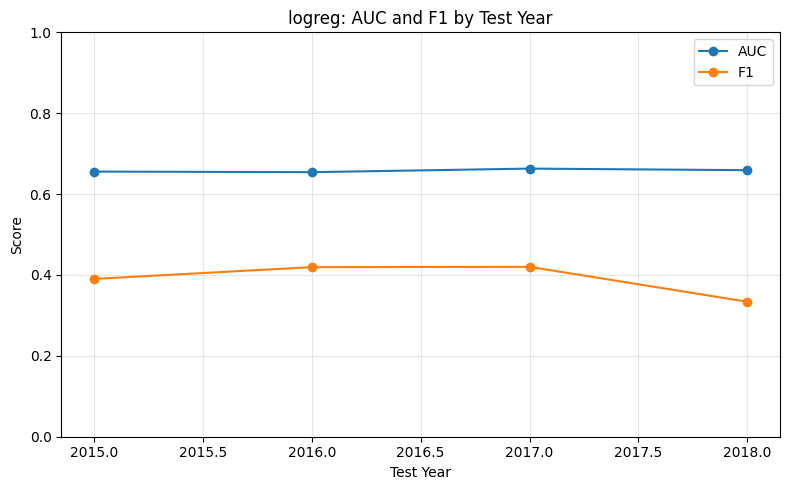

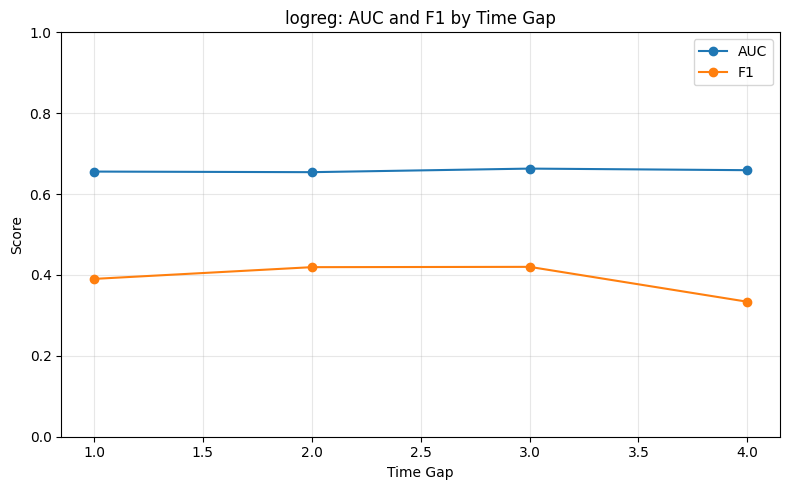

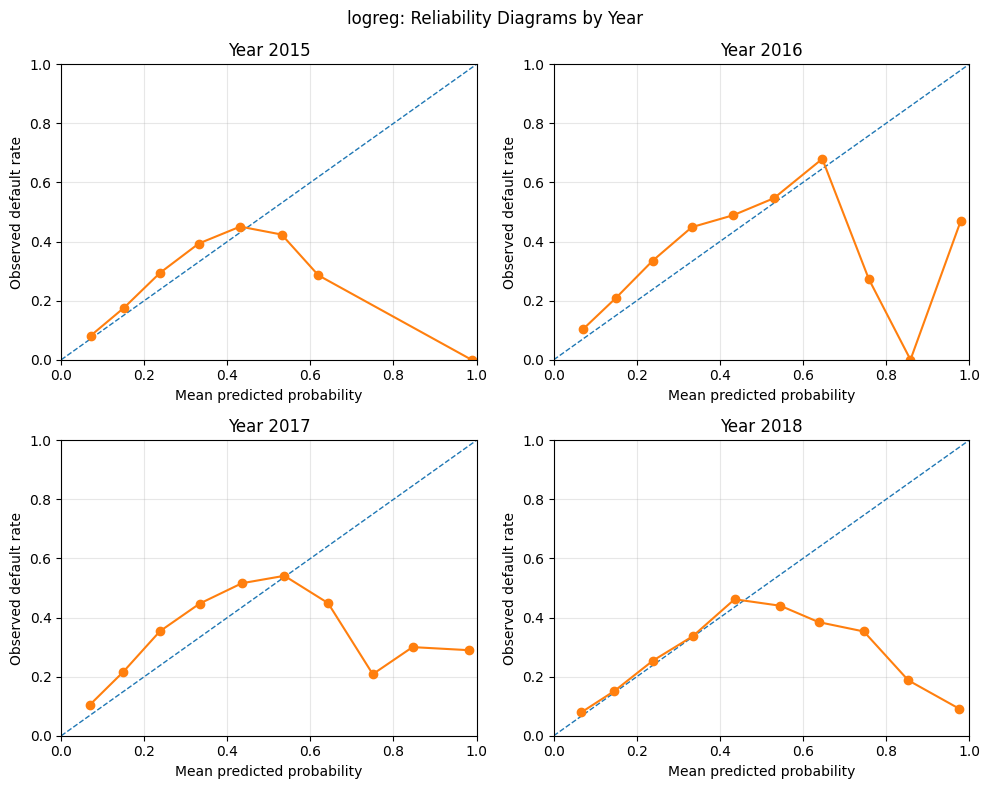

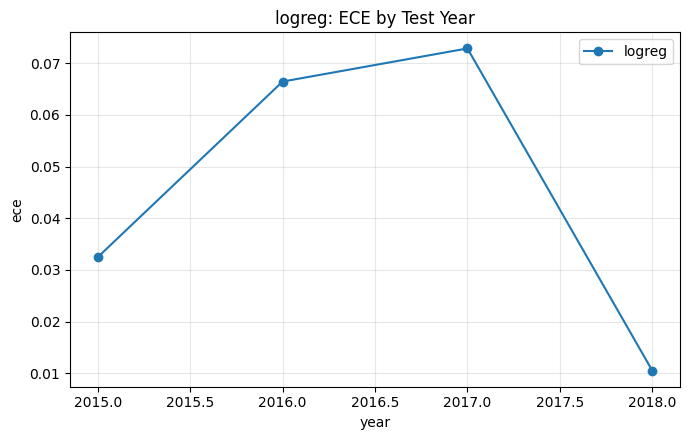

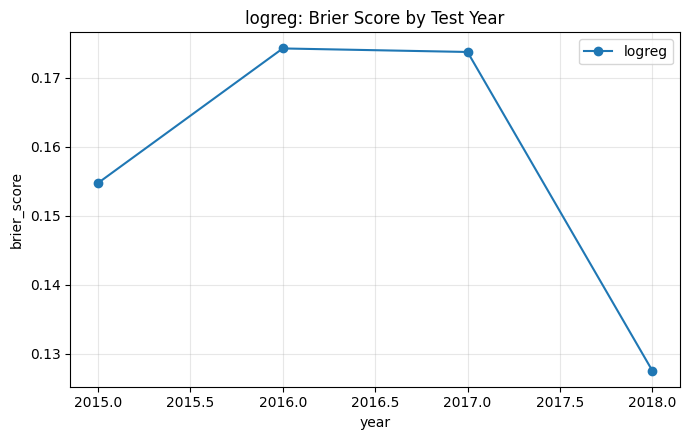

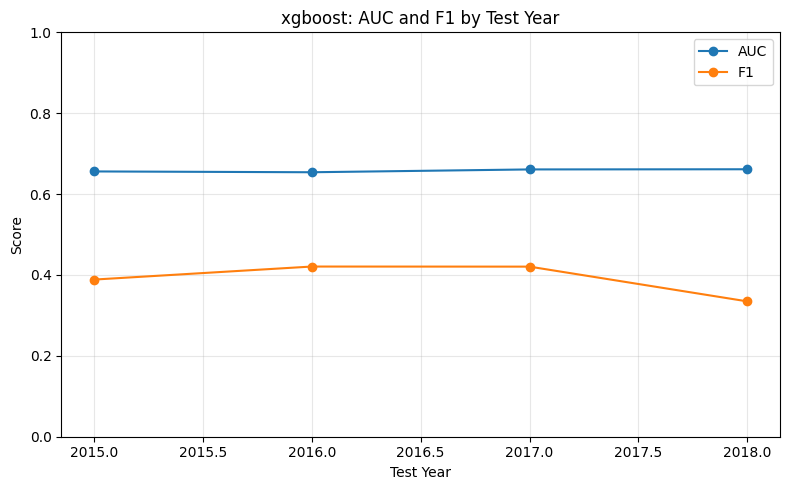

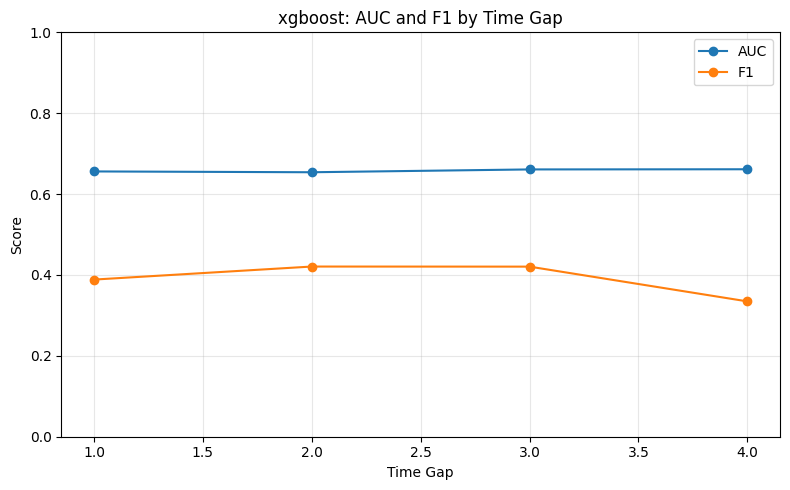

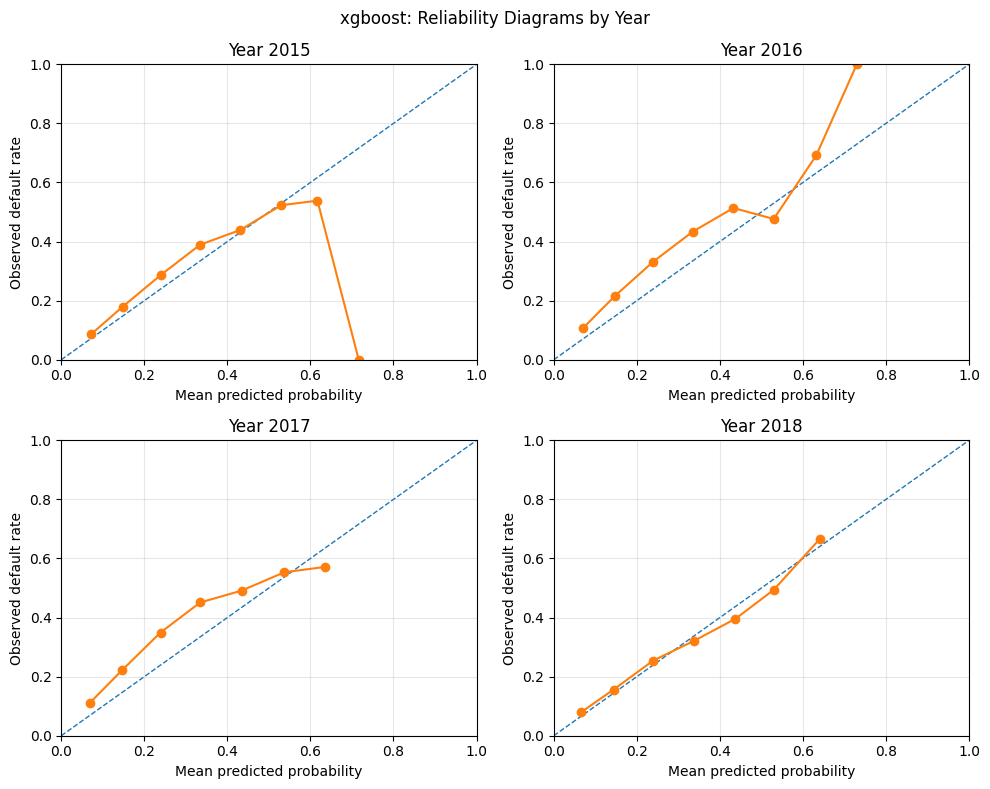

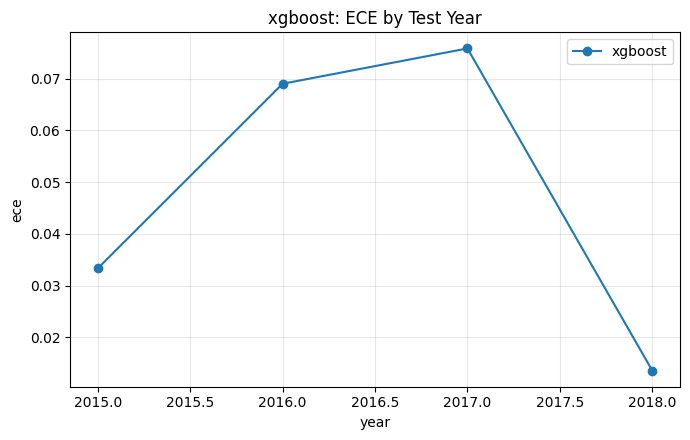

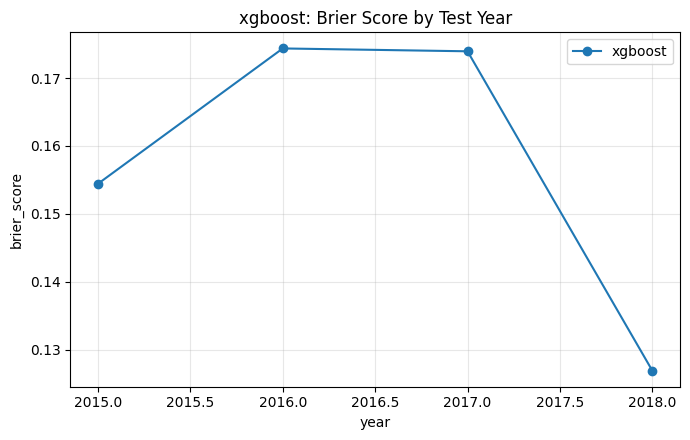

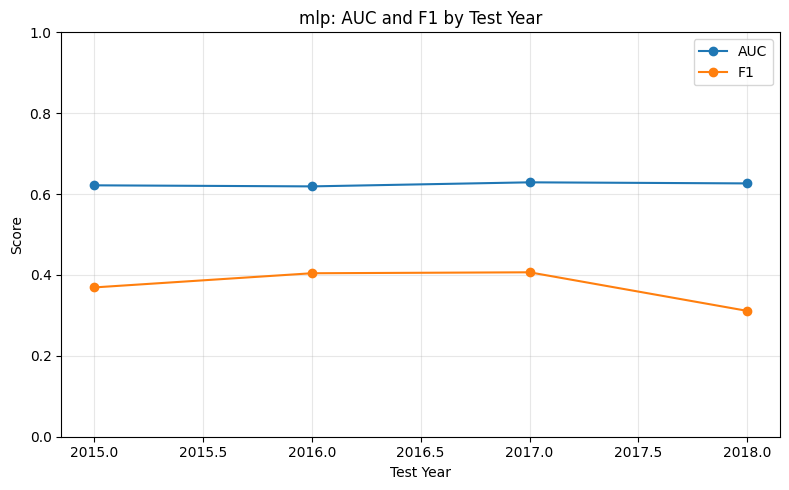

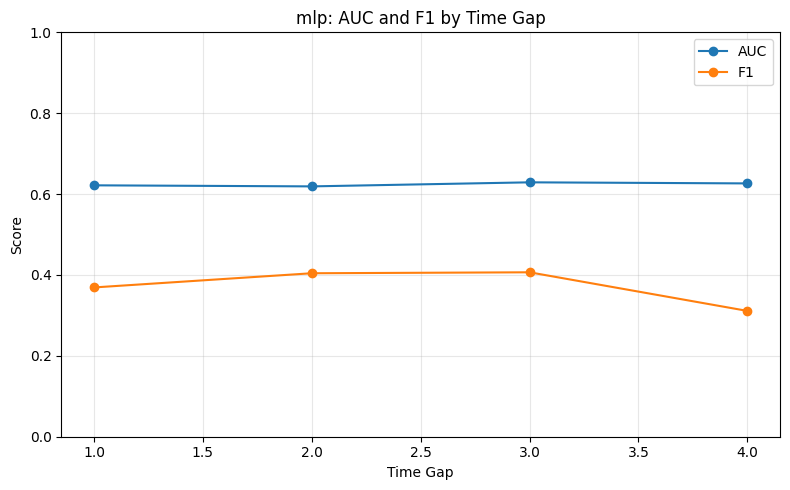

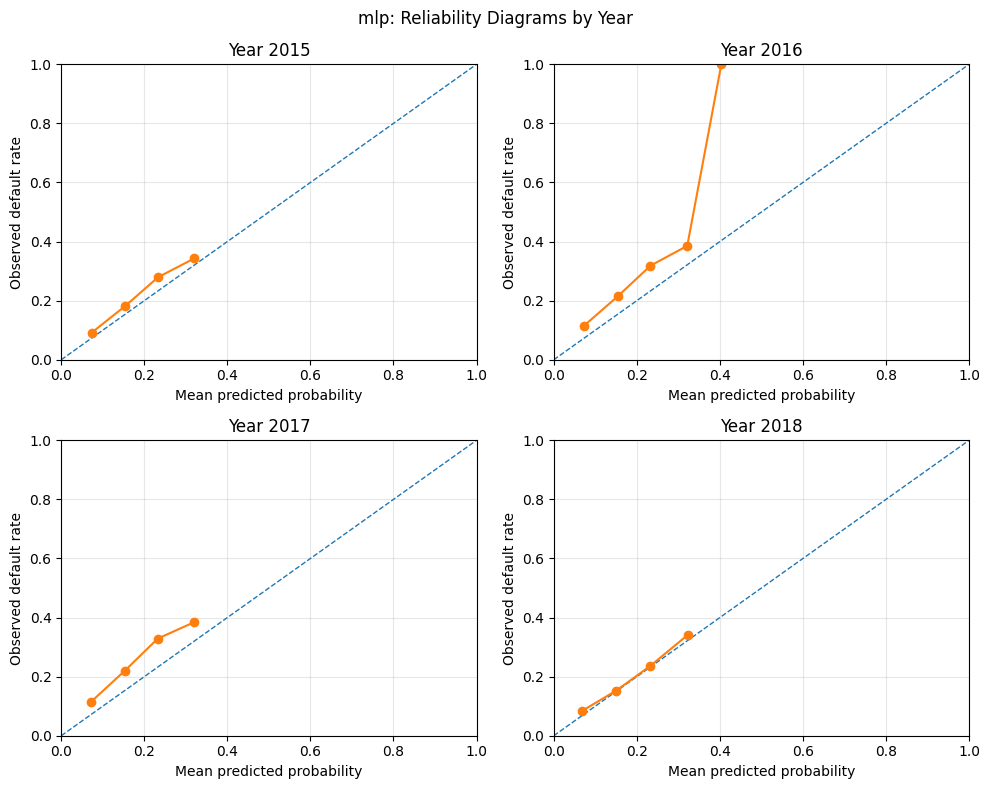

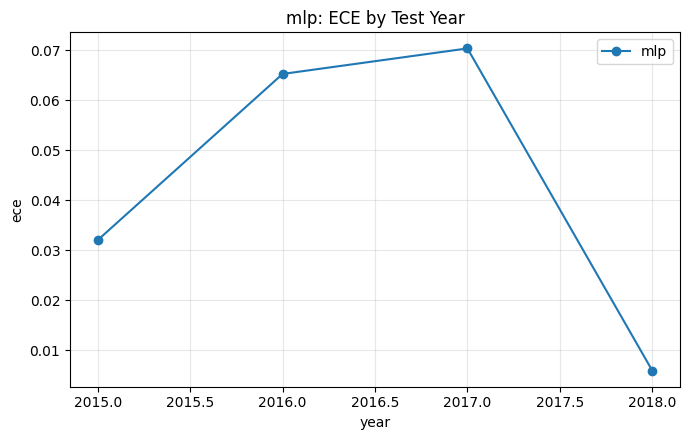

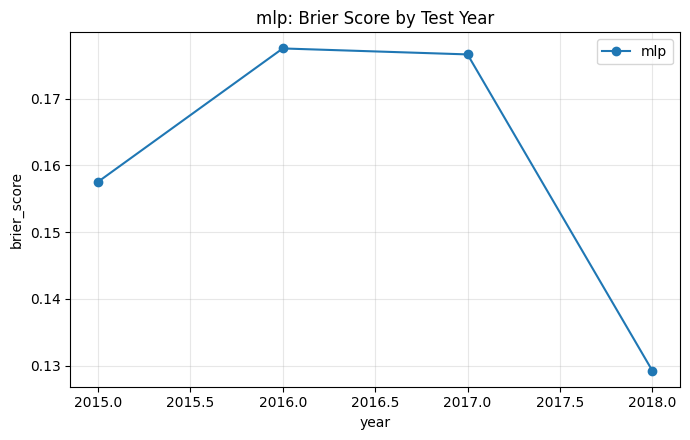

In [12]:
logreg_model, logreg_best_row, logreg_threshold_df, logreg_results, logreg_calibration, logreg_reliability = run_tuned_model(
    model_name="logreg",
    fit_fn=fit_logistic_pipeline,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    feature_groups=feature_groups,
)

xgboost_model, xgboost_best_row, xgboost_threshold_df, xgboost_results, xgboost_calibration, xgboost_reliability = run_tuned_model(
    model_name="xgboost",
    fit_fn=fit_xgboost_pipeline,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    feature_groups=feature_groups,
    fit_kwargs={"config": XGB_CONFIG},
)

mlp_model, mlp_best_row, mlp_threshold_df, mlp_results, mlp_calibration, mlp_reliability = run_tuned_model(
    model_name="mlp",
    fit_fn=fit_mlp_pipeline,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    feature_groups=feature_groups,
    fit_kwargs={"config": MLP_CONFIG},
)

## 12. Sample-matched LLM vs structured-model comparison

This section evaluates logistic regression, XGBoost, MLP, and the LLM on the exact same sampled validation/test rows. This makes the LLM extension directly comparable to the structured benchmark despite using a sample rather than the full validation/test set.

In [ ]:
# Sample-matched comparison:
# Evaluate the structured models and the LLM on the exact same validation/test rows.

if "llm_temporal_eval_predictions_df" not in globals():
    llm_temporal_eval_predictions_df = pd.read_csv(
        RESULTS_DIR / "llm_temporal_eval_predictions.csv"
    )

llm_temporal_eval_predictions_df = llm_temporal_eval_predictions_df[
    llm_temporal_eval_predictions_df["llm_error"].isna()
    & llm_temporal_eval_predictions_df["llm_default_probability"].notna()
].copy()

print("LLM rows used for sample-matched comparison:", len(llm_temporal_eval_predictions_df))

sample_matched_outputs = run_sample_matched_comparison(
    val_df=val_df,
    test_df=test_df,
    llm_predictions_df=llm_temporal_eval_predictions_df,
    models={
        "logreg": logreg_model,
        "xgboost": xgboost_model,
        "mlp": mlp_model,
    },
    feature_cols=feature_groups["feature_cols"],
    results_dir=RESULTS_DIR,
    llm_model_name=LLM_MODEL,
    id_col="id",
)

print("Sample-matched model summary")
display(sample_matched_outputs["sample_matched_model_summary"])

print("Sample-matched yearly metrics")
display(sample_matched_outputs["sample_matched_yearly_metrics"])

## 13. Feature-reliance analysis

This section extracts feature-reliance artifacts for the two most interpretable structured models: logistic regression and XGBoost. Logistic regression is summarized using absolute coefficient magnitude after preprocessing, while XGBoost is summarized using tree-based feature importances. One-hot encoded categorical features are aggregated back to their original feature columns.

In [ ]:
feature_reliance_outputs = save_feature_reliance_outputs(
    logreg_model=logreg_model,
    xgboost_model=xgboost_model,
    feature_groups=feature_groups,
    results_dir=RESULTS_DIR,
    top_n=15,
)

print("Top logistic regression features")
display(feature_reliance_outputs["logreg_feature_importance"].head(15))

print("Top XGBoost features")
display(feature_reliance_outputs["xgboost_feature_importance"].head(15))

print("Top-feature overlap between logistic regression and XGBoost")
display(feature_reliance_outputs["feature_importance_overlap"])

## 14. Best validation thresholds

In [13]:

best_thresholds_df = pd.DataFrame([
    {"model": "logreg", **logreg_best_row},
    {"model": "xgboost", **xgboost_best_row},
    {"model": "mlp", **mlp_best_row},
]).sort_values("model").reset_index(drop=True)

display(best_thresholds_df)
best_thresholds_df.to_csv(RESULTS_DIR / "best_thresholds.csv", index=False)


,model,threshold,f1,pred_positive_rate,pred_positives
0,logreg,0.174337,0.362897,0.441767,98559.0
1,mlp,0.156925,0.342234,0.586346,130815.0
2,xgboost,0.162954,0.364302,0.477911,106623.0


## 15. Final comparison tables


In [14]:
comparison_df = pd.concat(
    [logreg_results, xgboost_results, mlp_results],
    ignore_index=True,
).sort_values(["model", "year"]).reset_index(drop=True)

calibration_comparison_df = pd.concat(
    [logreg_calibration, xgboost_calibration, mlp_calibration],
    ignore_index=True,
).sort_values(["model", "year"]).reset_index(drop=True)

reliability_comparison_df = pd.concat(
    [logreg_reliability, xgboost_reliability, mlp_reliability],
    ignore_index=True,
).sort_values(["model", "year", "bin_id"]).reset_index(drop=True)

# Only merge in calibration-specific columns that are not already in comparison_df
calibration_cols_to_merge = [
    "model",
    "year",
    "time_gap",
    "threshold",
    "mean_pred",
    "brier_score",
    "ece",
    "abs_mean_prob_minus_default_rate",
]

# If comparison_df does NOT already contain default_rate, include it from calibration
if "default_rate" not in comparison_df.columns and "default_rate" in calibration_comparison_df.columns:
    calibration_cols_to_merge.insert(4, "default_rate")

performance_calibration_df = comparison_df.merge(
    calibration_comparison_df[calibration_cols_to_merge],
    on=["model", "year", "time_gap", "threshold"],
    how="inner",
    validate="one_to_one",
).sort_values(["model", "year"]).reset_index(drop=True)

display(comparison_df)
display(calibration_comparison_df)
display(performance_calibration_df)

comparison_df.to_csv(
    RESULTS_DIR / "temporal_metrics_all_models.csv",
    index=False,
)

calibration_comparison_df.to_csv(
    RESULTS_DIR / "temporal_calibration_all_models.csv",
    index=False,
)

reliability_comparison_df.to_csv(
    RESULTS_DIR / "reliability_bins_all_models.csv",
    index=False,
)

performance_calibration_df.to_csv(
    RESULTS_DIR / "performance_calibration_comparison.csv",
    index=False,
)

,year,n_rows,default_rate,pred_positive_rate,auc,f1,time_gap,model,threshold
0,2015,375543,0.201846,0.443571,0.655679,0.390260,1,logreg,0.174337
1,2016,293057,0.232818,0.422737,0.654201,0.419301,2,logreg,0.174337
2,2017,169117,0.231272,0.380346,0.663032,0.420071,3,logreg,0.174337
3,2018,56160,0.157514,0.321225,0.659125,0.333780,4,logreg,0.174337
4,2015,375543,0.201846,0.585669,0.621669,0.369148,1,mlp,0.156925
5,2016,293057,0.232818,0.571861,0.619051,0.404237,2,mlp,0.156925
6,2017,169117,0.231272,0.530219,0.629079,0.406597,3,mlp,0.156925
7,2018,56160,0.157514,0.465260,0.626421,0.311137,4,mlp,0.156925
8,2015,375543,0.201846,0.475772,0.656025,0.388580,1,xgboost,0.162954
9,2016,293057,0.232818,0.450059,0.654005,0.420823,2,xgboost,0.162954


,n_rows,default_rate,mean_pred,brier_score,ece,abs_mean_prob_minus_default_rate,year,time_gap,model,threshold
0,375543,0.201846,0.169474,0.154750,0.032468,0.032373,2015,1,logreg,0.174337
1,293057,0.232818,0.166507,0.174269,0.066448,0.066311,2016,2,logreg,0.174337
2,169117,0.231272,0.159497,0.173757,0.072858,0.071775,2017,3,logreg,0.174337
3,56160,0.157514,0.149178,0.127545,0.010513,0.008337,2018,4,logreg,0.174337
4,375543,0.201846,0.169801,0.157532,0.032046,0.032046,2015,1,mlp,0.156925
5,293057,0.232818,0.167596,0.177520,0.065222,0.065222,2016,2,mlp,0.156925
6,169117,0.231272,0.160957,0.176625,0.070315,0.070315,2017,3,mlp,0.156925
7,56160,0.157514,0.151534,0.129242,0.005980,0.005980,2018,4,mlp,0.156925
8,375543,0.201846,0.168513,0.154434,0.033348,0.033333,2015,1,xgboost,0.162954
9,293057,0.232818,0.163864,0.174357,0.069008,0.068954,2016,2,xgboost,0.162954


,year,n_rows,default_rate,pred_positive_rate,auc,f1,time_gap,model,threshold,mean_pred,brier_score,ece,abs_mean_prob_minus_default_rate
0,2015,375543,0.201846,0.443571,0.655679,0.390260,1,logreg,0.174337,0.169474,0.154750,0.032468,0.032373
1,2016,293057,0.232818,0.422737,0.654201,0.419301,2,logreg,0.174337,0.166507,0.174269,0.066448,0.066311
2,2017,169117,0.231272,0.380346,0.663032,0.420071,3,logreg,0.174337,0.159497,0.173757,0.072858,0.071775
3,2018,56160,0.157514,0.321225,0.659125,0.333780,4,logreg,0.174337,0.149178,0.127545,0.010513,0.008337
4,2015,375543,0.201846,0.585669,0.621669,0.369148,1,mlp,0.156925,0.169801,0.157532,0.032046,0.032046
5,2016,293057,0.232818,0.571861,0.619051,0.404237,2,mlp,0.156925,0.167596,0.177520,0.065222,0.065222
6,2017,169117,0.231272,0.530219,0.629079,0.406597,3,mlp,0.156925,0.160957,0.176625,0.070315,0.070315
7,2018,56160,0.157514,0.465260,0.626421,0.311137,4,mlp,0.156925,0.151534,0.129242,0.005980,0.005980
8,2015,375543,0.201846,0.475772,0.656025,0.388580,1,xgboost,0.162954,0.168513,0.154434,0.033348,0.033333
9,2016,293057,0.232818,0.450059,0.654005,0.420823,2,xgboost,0.162954,0.163864,0.174357,0.069008,0.068954


In [15]:
summary_cols = [
    "model",
    "year",
    "time_gap",
    "threshold",
    "auc",
    "f1",
    "pred_positive_rate",
    "default_rate",
    "mean_pred",
    "ece",
    "brier_score",
    "abs_mean_prob_minus_default_rate",
]

summary_df = (
    performance_calibration_df[summary_cols]
    .sort_values(["model", "year"])
    .reset_index(drop=True)
)

display(summary_df)
summary_df.to_csv(RESULTS_DIR / "summary_table.csv", index=False)

,model,year,time_gap,threshold,auc,f1,pred_positive_rate,default_rate,mean_pred,ece,brier_score,abs_mean_prob_minus_default_rate
0,logreg,2015,1,0.174337,0.655679,0.390260,0.443571,0.201846,0.169474,0.032468,0.154750,0.032373
1,logreg,2016,2,0.174337,0.654201,0.419301,0.422737,0.232818,0.166507,0.066448,0.174269,0.066311
2,logreg,2017,3,0.174337,0.663032,0.420071,0.380346,0.231272,0.159497,0.072858,0.173757,0.071775
3,logreg,2018,4,0.174337,0.659125,0.333780,0.321225,0.157514,0.149178,0.010513,0.127545,0.008337
4,mlp,2015,1,0.156925,0.621669,0.369148,0.585669,0.201846,0.169801,0.032046,0.157532,0.032046
5,mlp,2016,2,0.156925,0.619051,0.404237,0.571861,0.232818,0.167596,0.065222,0.177520,0.065222
6,mlp,2017,3,0.156925,0.629079,0.406597,0.530219,0.231272,0.160957,0.070315,0.176625,0.070315
7,mlp,2018,4,0.156925,0.626421,0.311137,0.465260,0.157514,0.151534,0.005980,0.129242,0.005980
8,xgboost,2015,1,0.162954,0.656025,0.388580,0.475772,0.201846,0.168513,0.033348,0.154434,0.033333
9,xgboost,2016,2,0.162954,0.654005,0.420823,0.450059,0.232818,0.163864,0.069008,0.174357,0.068954


### Final performance + calibration + drift summary

In [ ]:
# Rename drift columns before merging to avoid ambiguous _x/_y suffixes.
drift_summary_for_merge = drift_summary_df.rename(
    columns={
        "n_rows": "drift_n_rows",
        "default_rate": "drift_default_rate",
    }
)

final_summary_df = performance_calibration_df.merge(
    drift_summary_for_merge,
    on="year",
    how="left",
    validate="many_to_one",
)

display(final_summary_df)

final_summary_df.to_csv(
    RESULTS_DIR / "final_performance_calibration_drift_summary.csv",
    index=False,
)

## 16. Final comparison plots


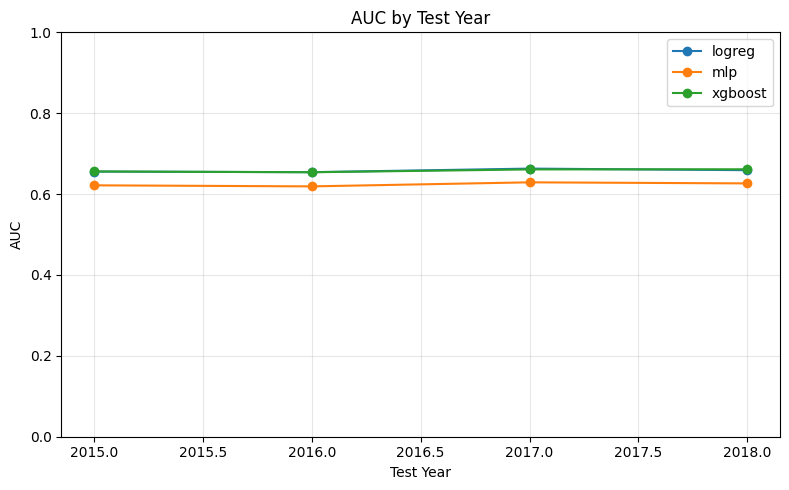

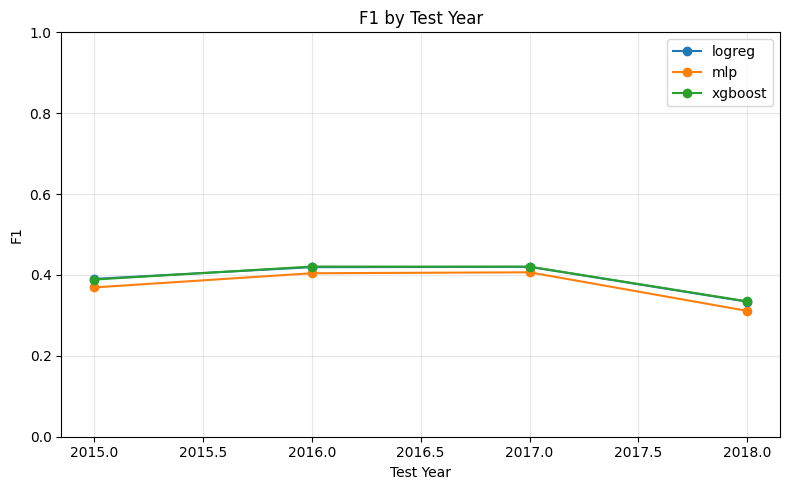

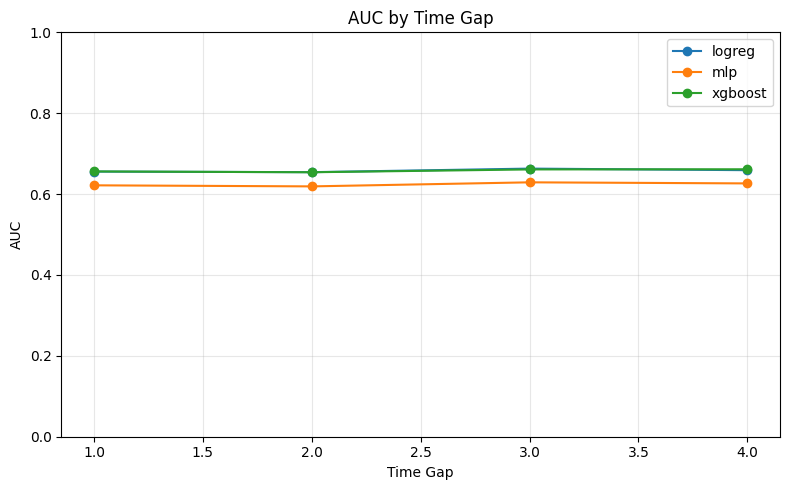

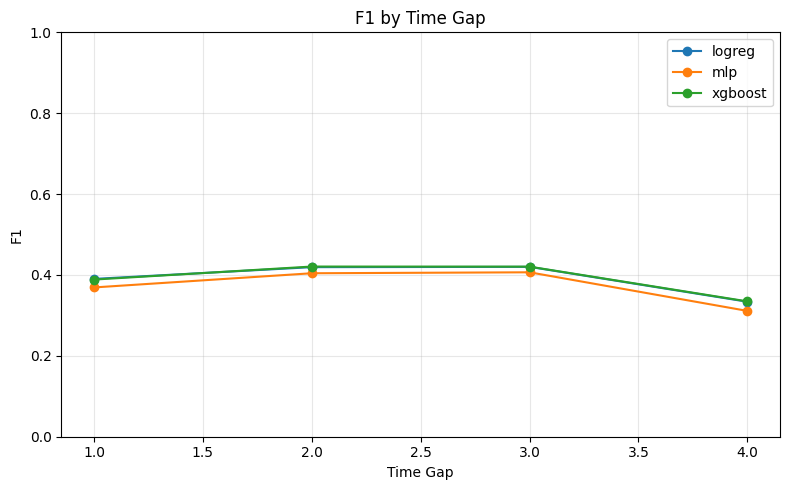

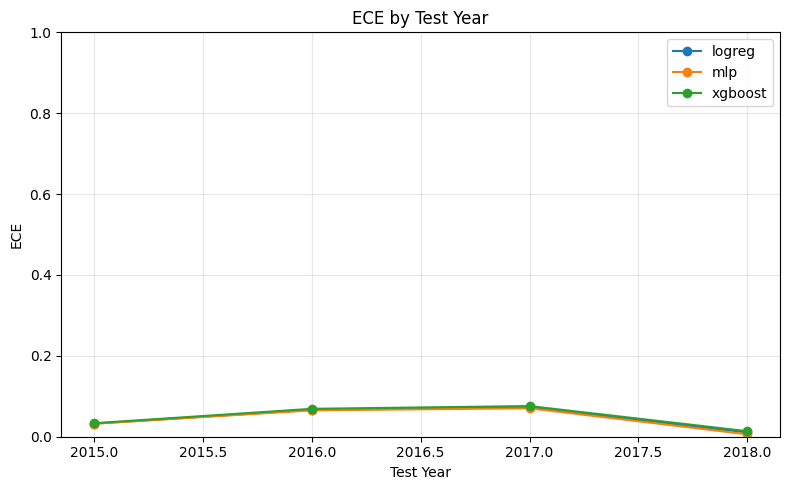

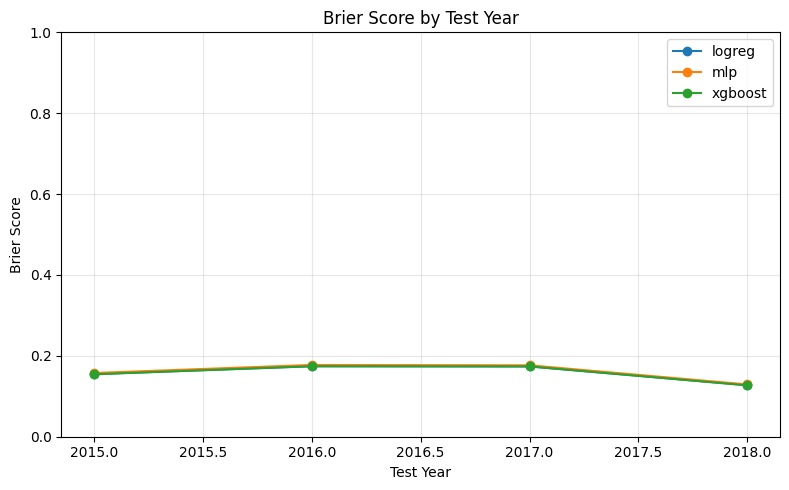

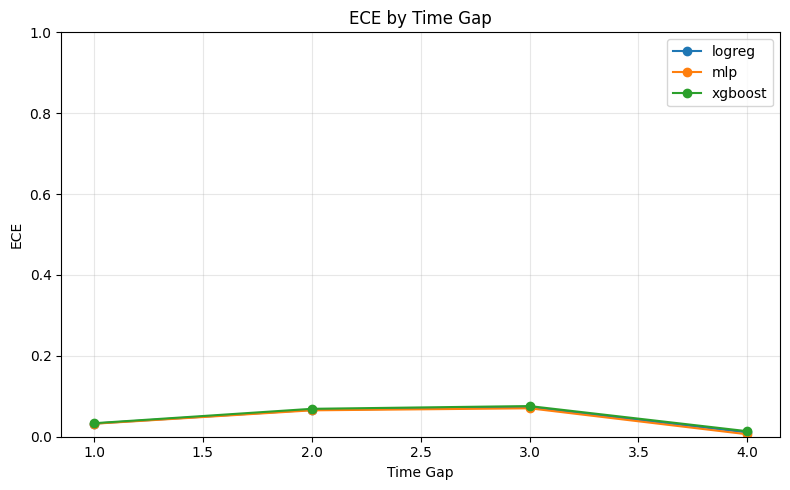

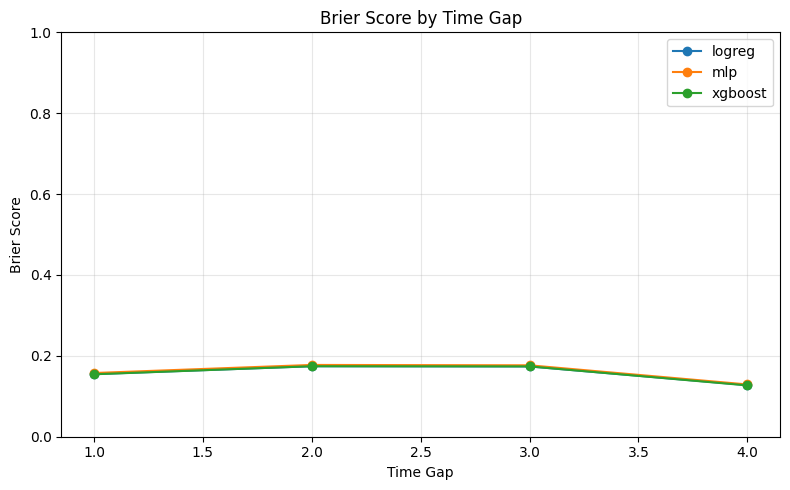

,model,year,time_gap,auc,f1,ece,brier_score,auc_drop_from_first_test_year,f1_drop_from_first_test_year,ece_change_from_first_test_year,brier_change_from_first_test_year
0,logreg,2015,1,0.655679,0.390260,0.032468,0.154750,0.000000,0.000000,0.000000,0.000000
1,logreg,2016,2,0.654201,0.419301,0.066448,0.174269,0.001479,-0.029041,0.033979,0.019519
2,logreg,2017,3,0.663032,0.420071,0.072858,0.173757,-0.007353,-0.029811,0.040390,0.019007
3,logreg,2018,4,0.659125,0.333780,0.010513,0.127545,-0.003446,0.056480,-0.021955,-0.027205
4,mlp,2015,1,0.621669,0.369148,0.032046,0.157532,0.000000,0.000000,0.000000,0.000000
5,mlp,2016,2,0.619051,0.404237,0.065222,0.177520,0.002618,-0.035089,0.033177,0.019988
6,mlp,2017,3,0.629079,0.406597,0.070315,0.176625,-0.007410,-0.037449,0.038269,0.019093
7,mlp,2018,4,0.626421,0.311137,0.005980,0.129242,-0.004752,0.058011,-0.026065,-0.028290
8,xgboost,2015,1,0.656025,0.388580,0.033348,0.154434,0.000000,0.000000,0.000000,0.000000
9,xgboost,2016,2,0.654005,0.420823,0.069008,0.174357,0.002020,-0.032243,0.035660,0.019923


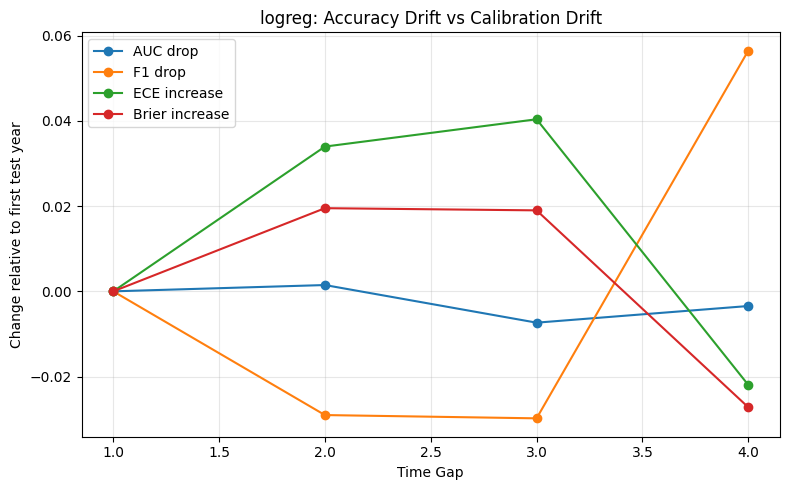

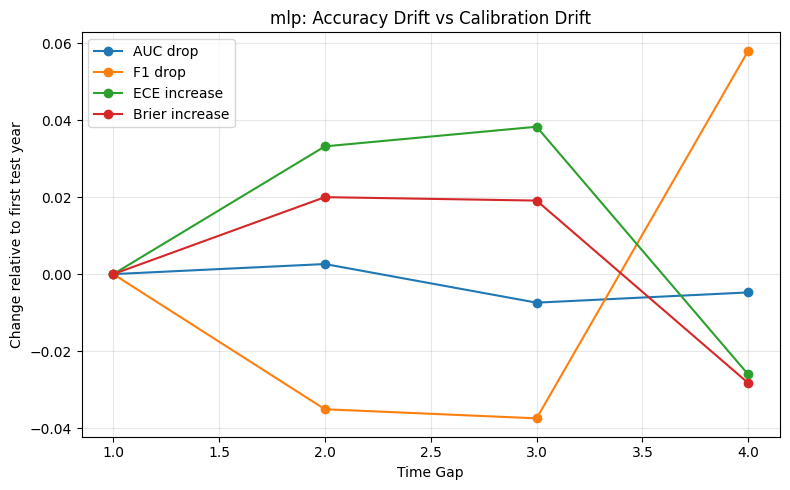

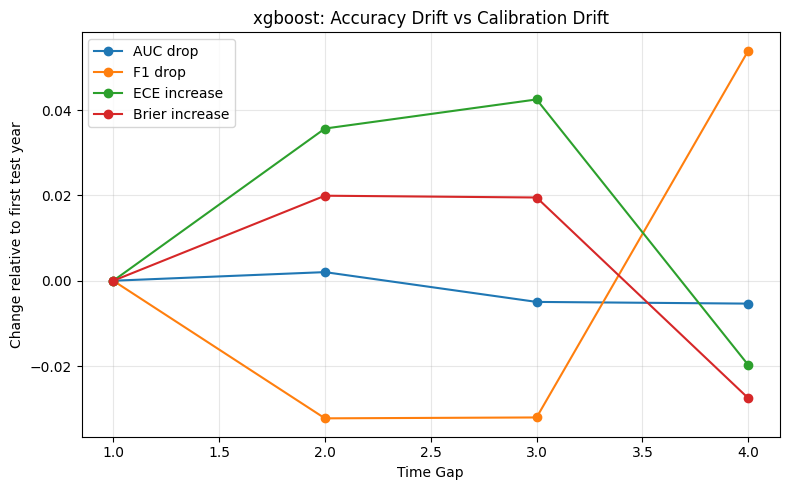

In [16]:
plot_comparison_metric(
    comparison_df,
    x_col="year",
    metric_col="auc",
    title="AUC by Test Year",
    output_name="comparison_auc_by_year.png",
    ylabel="AUC",
)

plot_comparison_metric(
    comparison_df,
    x_col="year",
    metric_col="f1",
    title="F1 by Test Year",
    output_name="comparison_f1_by_year.png",
    ylabel="F1",
)

plot_comparison_metric(
    comparison_df,
    x_col="time_gap",
    metric_col="auc",
    title="AUC by Time Gap",
    output_name="comparison_auc_by_time_gap.png",
    ylabel="AUC",
)

plot_comparison_metric(
    comparison_df,
    x_col="time_gap",
    metric_col="f1",
    title="F1 by Time Gap",
    output_name="comparison_f1_by_time_gap.png",
    ylabel="F1",
)

plot_comparison_metric(
    calibration_comparison_df,
    x_col="year",
    metric_col="ece",
    title="ECE by Test Year",
    output_name="comparison_ece_by_year.png",
    ylabel="ECE",
)

plot_comparison_metric(
    calibration_comparison_df,
    x_col="year",
    metric_col="brier_score",
    title="Brier Score by Test Year",
    output_name="comparison_brier_by_year.png",
    ylabel="Brier Score",
)

plot_comparison_metric(
    calibration_comparison_df,
    x_col="time_gap",
    metric_col="ece",
    title="ECE by Time Gap",
    output_name="comparison_ece_by_time_gap.png",
    ylabel="ECE",
)

plot_comparison_metric(
    calibration_comparison_df,
    x_col="time_gap",
    metric_col="brier_score",
    title="Brier Score by Time Gap",
    output_name="comparison_brier_by_time_gap.png",
    ylabel="Brier Score",
)

# Direct checkpoint-4 drift comparison:
# compare how accuracy metrics and calibration metrics move relative to each model's first test year
drift_frames = []

for model_name, model_df in performance_calibration_df.groupby("model"):
    model_df = model_df.sort_values("year").reset_index(drop=True)
    baseline = model_df.iloc[0]

    drift_df_model = model_df.copy()
    drift_df_model["auc_drop_from_first_test_year"] = baseline["auc"] - drift_df_model["auc"]
    drift_df_model["f1_drop_from_first_test_year"] = baseline["f1"] - drift_df_model["f1"]
    drift_df_model["ece_change_from_first_test_year"] = drift_df_model["ece"] - baseline["ece"]
    drift_df_model["brier_change_from_first_test_year"] = (
        drift_df_model["brier_score"] - baseline["brier_score"]
    )

    drift_frames.append(drift_df_model)

drift_comparison_df = (
    pd.concat(drift_frames, ignore_index=True)
    .sort_values(["model", "year"])
    .reset_index(drop=True)
)

display(
    drift_comparison_df[
        [
            "model",
            "year",
            "time_gap",
            "auc",
            "f1",
            "ece",
            "brier_score",
            "auc_drop_from_first_test_year",
            "f1_drop_from_first_test_year",
            "ece_change_from_first_test_year",
            "brier_change_from_first_test_year",
        ]
    ]
)

drift_comparison_df.to_csv(
    RESULTS_DIR / "drift_comparison_table.csv",
    index=False,
)

for model_name, model_df in drift_comparison_df.groupby("model"):
    model_df = model_df.sort_values("time_gap")

    plt.figure(figsize=(8, 5))
    plt.plot(
        model_df["time_gap"],
        model_df["auc_drop_from_first_test_year"],
        marker="o",
        label="AUC drop",
    )
    plt.plot(
        model_df["time_gap"],
        model_df["f1_drop_from_first_test_year"],
        marker="o",
        label="F1 drop",
    )
    plt.plot(
        model_df["time_gap"],
        model_df["ece_change_from_first_test_year"],
        marker="o",
        label="ECE increase",
    )
    plt.plot(
        model_df["time_gap"],
        model_df["brier_change_from_first_test_year"],
        marker="o",
        label="Brier increase",
    )
    plt.xlabel("Time Gap")
    plt.ylabel("Change relative to first test year")
    plt.title(f"{model_name}: Accuracy Drift vs Calibration Drift")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        RESULTS_DIR / f"{model_name}_accuracy_vs_calibration_drift.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

## 17. Final output check


In [17]:

print("Saved outputs to:", RESULTS_DIR)
for p in sorted(RESULTS_DIR.iterdir()):
    print("-", p.name)


Saved outputs to: /content/CS-4365/results
- best_thresholds.csv
- comparison_auc_by_time_gap.png
- comparison_auc_by_year.png
- comparison_brier_by_time_gap.png
- comparison_brier_by_year.png
- comparison_ece_by_time_gap.png
- comparison_ece_by_year.png
- comparison_f1_by_time_gap.png
- comparison_f1_by_year.png
- drift_comparison_table.csv
- llm_eval_sample.csv
- llm_eval_sample.jsonl
- logreg_accuracy_vs_calibration_drift.png
- logreg_auc_f1_by_time_gap.png
- logreg_auc_f1_by_year.png
- logreg_brier_by_year.png
- logreg_ece_by_year.png
- logreg_reliability_by_year.png
- logreg_validation_threshold_search.csv
- mlp_accuracy_vs_calibration_drift.png
- mlp_auc_f1_by_time_gap.png
- mlp_auc_f1_by_year.png
- mlp_brier_by_year.png
- mlp_ece_by_year.png
- mlp_reliability_by_year.png
- mlp_validation_threshold_search.csv
- performance_calibration_comparison.csv
- reliability_bins_all_models.csv
- reliability_bins_logreg.csv
- reliability_bins_mlp.csv
- reliability_bins_xgboost.csv
- summary_